# Weeks 5–8 Consolidation: NumPy and pandas Essentials

In this lecture we will recap and consolidate our knowledge from weeks 5-8.

## Learning outcomes

By the end of this session you should be able to:

1. Explain **why** `numpy.ndarray` exists and how it differs fundamentally from a Python `list` (fixed size, single dtype, contiguous memory, speed).
2. Create arrays in the common ways (`np.array`, `np.arange`, `np.zeros`/`np.ones`/`np.full`) and inspect `.shape`, `.dtype`.
3. Slice and index arrays confidently, and understand the **"slices are views" gotcha** that catches almost everyone out at least once.
4. Use broadcasting to write fast, loop-free array arithmetic.
5. Explain how a `pandas.DataFrame` relates to a NumPy array, and create one from lists / dicts / arrays.
6. Select rows, columns and cells using `.loc`, `.iloc`, `.at`, `.iat`, and boolean masks.
7. Read a real CSV into pandas and get a fast statistical overview with `.describe()` and `.filter()`.
8. Build a basic, readable plot using matplotlib's object-oriented interface (`Figure`/`Axes`).

---

## 1. Why NumPy? Arrays vs lists

A Python `list` is flexible: it can hold mixed types and grows/shrinks freely. That flexibility has a cost lists are not efficient for numerical (scientific) computing.

`numpy` gives us the `ndarray` ("n-dimensional array"), which trades flexibility for speed by:
- fixing the **size** and **dtype** up front,
- storing data in a single **contiguous block of memory**.

> **Key idea:** `numpy` is "closer to the metal". An array is *nothing* like a list, even though it can look similar when printed.

In [1]:
import numpy as np

### Lists are flexible but slow for numeric work

In [2]:
python_list = list(range(1_000_000))
numpy_array = np.arange(1_000_000)

%timeit sum(python_list)
%timeit np.sum(numpy_array)

2.39 ms ± 200 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
96.9 μs ± 281 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


The array version is typically an order of magnitude (or more) faster. This matters as soon as you're running simulations or processing real datasets.

### Arrays are fixed-size and single-dtype. Let's try to break them

In [3]:
my_arr = np.array([1, 2, 3, 4, 5, 6])

# 1. No append - arrays are fixed size
try:
    my_arr.append(7)
except AttributeError as e:
    print("AttributeError:", e)

AttributeError: 'numpy.ndarray' object has no attribute 'append'


In [4]:
# 2. Assigning an incompatible type raises an error
try:
    my_arr[0] = 'Zero'
except ValueError as e:
    print("ValueError:", e)

ValueError: invalid literal for int() with base 10: 'Zero'


In [5]:
# 3. Assigning a float silently truncates - a much sneakier bug!
my_arr[0] = 99.999999
print("Silently truncated:", my_arr)

Silently truncated: [99  2  3  4  5  6]


**Takeaway:** NumPy is fast because it works "closer to the metal" in fixed, contiguous memory. That efficiency is exactly what causes the append error and the silent truncation above the same design decision, two different symptoms.

---

## 2. Creating arrays and inspecting them

The tools you'll use most often:

| Function | Purpose |
|---|---|
| `np.array(list_or_nested_list)` | From existing data (hard-coded / small examples) |
| `np.arange(start, stop, step)` | Sequence of numbers, like `range` |
| `np.zeros(shape)` / `np.ones(shape)` / `np.full(shape, value)` | Pre-filled array of known size |
| `.shape` | Tuple describing dimensions |
| `.dtype` | The single data type stored |

In [6]:
# a 1D array ("a vector")
vec = np.array([88.9, 45.6, 20.4], dtype=np.float64)
print(vec, vec.dtype, vec.shape)

[88.9 45.6 20.4] float64 (3,)


In [7]:
# a 2D array ("matrix")
mat = np.array([[1, 2], [3, 4]])
print(mat)
print("shape:", mat.shape)
print("element [1, 1]:", mat[1, 1])  # zero-indexed, like lists

[[1 2]
 [3 4]]
shape: (2, 2)
element [1, 1]: 4


In [8]:
zeros = np.zeros(shape=5, dtype=np.int8)
ones = np.ones(shape=5, dtype=np.int8)
fives = np.full(shape=5, fill_value=5, dtype=np.int8)
print(zeros)
print(ones)
print(fives)

[0 0 0 0 0]
[1 1 1 1 1]
[5 5 5 5 5]


## 3. Slicing, indexing, and the "views" gotcha

Slicing syntax `array[start:end:step]` works just like lists i.e. `start` included, `end` excluded.

For 2D arrays, use `array[row, col]`, and `:` to mean "all" along that axis.

In [9]:
original = np.array([[1, 2], [3, 4], [5, 6]])
print("middle row:", original[1, :])
print("first column:", original[:, 0])

middle row: [3 4]
first column: [1 3 5]


### The most important gotcha in this whole recap

A slice of a NumPy array is a **view** onto the same memory. **It is not a copy**. Updating the slice updates the original array. This is *different* from Python list slicing, which does copy.

In [10]:
# Python list slice -> COPY. Original is untouched.
original_list = [1, 2, 3, 4, 5]
list_slice = original_list[1:3]
list_slice[0] = 999
print("list slice:", list_slice)
print("original list (unchanged):", original_list)

list slice: [999, 3]
original list (unchanged): [1, 2, 3, 4, 5]


In [11]:
# NumPy array slice -> VIEW. Original IS changed!
original_array = np.array([1, 2, 3, 4, 5])
array_slice = original_array[1:3]
array_slice[0] = 999
print("array slice:", array_slice)
print("original array (CHANGED!):", original_array)

array slice: [999   3]
original array (CHANGED!): [  1 999   3   4   5]


### Boolean indexing

You can select elements matching a condition directly. This is heavily used in pandas as well.

In [12]:
vals = np.arange(10)
vals

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [13]:
mask = vals > 5
print(mask)
print(vals[mask])  # equivalently: vals[vals > 5]

[False False False False False False  True  True  True  True]
[6 7 8 9]


## 4. Broadcasting

Broadcasting lets NumPy apply an operation between arrays of different (but compatible) shapes, without writing an explicit loop — this is how you get fast, readable array algebra.

In [14]:
x = np.array([10, 20, 30, 40])
y = x + 5  # 5 is "stretched" to [5, 5, 5, 5]
print(y)

[15 25 35 45]


In [15]:
# equivalent
x = np.array([10, 20, 30, 40])
y = x + np.array([5, 5, 5, 5])
print(y)

[15 25 35 45]


In [16]:
a = np.array([[0, 1, 2],
              [3, 4, 5],
              [6, 7, 8],
              [9, 10, 11]])
b = np.array([1, 2, 3])
print(a + b)  # b is stretched across every row

[[ 1  3  5]
 [ 4  6  8]
 [ 7  9 11]
 [10 12 14]]


In [17]:
a.shape

(4, 3)

In [18]:
b.shape

(3,)

**Broadcasting rule:** for two arrays to broadcast, their trailing dimensions must either match, or one of them must be 1. If shapes are incompatible you get a `ValueError`.

## 5. From arrays to DataFrames: pandas basics

`pandas` builds on top of `numpy` to give a higher-level API for real, labelled, tabular data. The two core objects:

- **`pd.Series`** think of it as one labelled column of data.
- **`pd.DataFrame`** a table made of Series, all sharing a common index.

The trade-off versus raw NumPy: pandas is easier to use for wrangling but has more overhead. For high-performance numerical algorithms, drop back down to `numpy`.

In [19]:
import pandas as pd

In [20]:
# a DataFrame from a dict of lists - the most common manual construction
bands = pd.DataFrame({
    'band': ['pantera', 'metallica', 'megadeth', 'anthrax'],
    'n_albums': [9, 10, 15, 11],
    'yr_formed': [1981, 1981, 1983, 1981],
    'active': [False, True, True, True]
})
bands

,band,n_albums,yr_formed,active
0,pantera,9,1981,False
1,metallica,10,1981,True
2,megadeth,15,1983,True
3,anthrax,11,1981,True


In [21]:
bands.info()  # dtypes + memory + non-null counts, always worth checking
bands.set_index('band', inplace=True)  # use a meaningful column as the index
bands

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   band       4 non-null      object
 1   n_albums   4 non-null      int64 
 2   yr_formed  4 non-null      int64 
 3   active     4 non-null      bool  
dtypes: bool(1), int64(2), object(1)
memory usage: 232.0+ bytes


,n_albums,yr_formed,active
band,,,
pantera,9,1981,False
metallica,10,1981,True
megadeth,15,1983,True
anthrax,11,1981,True


## 6. Selecting data: `.loc`, `.iloc`, `.at`, `.iat`, boolean masks

| Accessor | Selects by | Notes |
|---|---|---|
| `.loc[row_label]` | label / name | inclusive on both ends when slicing |
| `.iloc[row_position]` | integer position | exclusive end, like normal Python slicing |
| `.at[row_label, col_label]` | single cell, by label | fast |
| `.iat[row_pos, col_pos]` | single cell, by position | fast |
| `df[boolean_mask]` / `df.loc[mask]` | rows meeting a condition | same idea as NumPy boolean indexing |

In [22]:
bands.loc['pantera']  # by name

n_albums         9
yr_formed     1981
active       False
Name: pantera, dtype: object

In [23]:
bands.iloc[2]  # by position (megadeth)

n_albums       15
yr_formed    1983
active       True
Name: megadeth, dtype: object

In [24]:
to_find = ['pantera', 'megadeth']
bands.loc[to_find]

,n_albums,yr_formed,active
band,,,
pantera,9,1981,False
megadeth,15,1983,True


In [25]:
cols = ['yr_formed', 'active']
rows = ['pantera', 'anthrax']
bands.loc[rows, cols]

,yr_formed,active
band,,
pantera,1981,False
anthrax,1981,True


In [26]:
bands.at['pantera', 'yr_formed']

np.int64(1981)

In [27]:
# boolean indexing - formed in or after 1983
recent = bands[bands['yr_formed'] >= 1983]
recent

,n_albums,yr_formed,active
band,,,
megadeth,15,1983,True


## 7. Working with a real dataset: read, describe, filter

Real datasets come from files/URLs and need summarising before you dive in. Two habits worth building now:

1. Always check `.info()` and `.shape` right after loading.
2. Use `.describe()` (optionally `.T` and `.filter(like=...)`) to get oriented fast, rather than scrolling through raw rows.

In [28]:
url = 'https://raw.githubusercontent.com/health-data-science-OR/hpdm139-datasets/main/wisconsin.csv'
df = pd.read_csv(url, index_col='id')
df = df.drop(labels='Unnamed: 0', axis=1)
print(df.shape)
df.info()

(569, 31)
<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se       

In [29]:
df.describe().T.round(2).head(10)  # transposed = one row per feature, easier to scan

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
texture_mean,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
perimeter_mean,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
area_mean,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
smoothness_mean,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16
compactness_mean,569.0,0.10,0.05,0.02,0.06,0.09,0.13,0.35
concavity_mean,569.0,0.09,0.08,0.00,0.03,0.06,0.13,0.43
concave points_mean,569.0,0.05,0.04,0.00,0.02,0.03,0.07,0.20
symmetry_mean,569.0,0.18,0.03,0.11,0.16,0.18,0.20,0.30
fractal_dimension_mean,569.0,0.06,0.01,0.05,0.06,0.06,0.07,0.10


In [30]:
# .filter(like=...) narrows columns by a naming pattern - handy with wide datasets
df.filter(like='mean').describe().T.round(2).head()

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
texture_mean,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
perimeter_mean,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
area_mean,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
smoothness_mean,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16


In [31]:
# combine a boolean mask with column filtering, just as we did with the small example above
threshold = df.describe().T.loc['area_mean', '75%']
extremes = df.loc[df['area_mean'] > threshold]
print(extremes.shape)
extremes.filter(like='smoothness').describe()

(142, 31)


,smoothness_mean,smoothness_se,smoothness_worst
count,142.000000,142.000000,142.000000
mean,0.100433,0.006653,0.138356
std,0.011829,0.003180,0.018561
min,0.073710,0.002667,0.087740
25%,0.092673,0.004951,0.124750
50%,0.099985,0.006106,0.139950
75%,0.107775,0.007547,0.150150
max,0.144700,0.031130,0.187300


---

## 8. Plotting using `matplotlib`

`pandas` plotting is convenient, but for full control over a figure you drop down to `matplotlib`'s object-oriented interface. This is the same interface used throughout week 8: create a `Figure`, add an `Axes` to it, then call plotting methods on the axes object.

The two lines to remember:

```python
fig = plt.figure(figsize=(12, 3))
ax = fig.add_subplot()
```

`fig` is the overall canvas; `ax` is what you actually plot onto and customise (labels, grid, ticks, legend).

In [32]:
import matplotlib.pyplot as plt

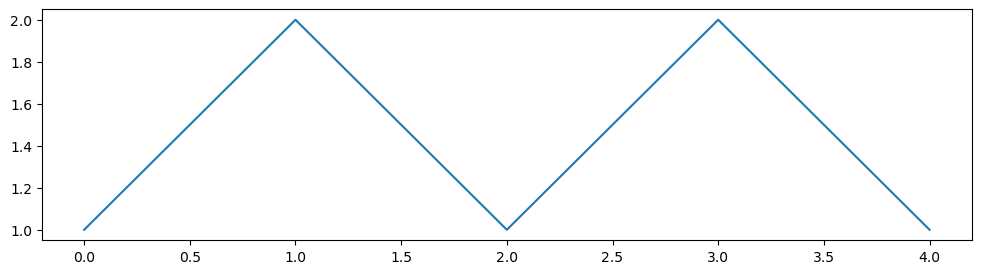

In [33]:
fig = plt.figure(figsize=(12, 3))
ax = fig.add_subplot()

dataset = [1, 2, 1, 2, 1]

# .plot returns a 2D line plot object
lineplot = ax.plot(dataset)

There is no real difference between plotting toy data and a real health dataset. We reuse the cleaned Netherlands COVID-19 dataset (`nethcovid`, wide-format with a `province, date` index) from week 8, and plot the daily positive cases for Groningen using the same `.loc` indexing skills from Section 6.

In [34]:
DATA_URL = 'https://raw.githubusercontent.com/health-data-science-OR/' \
            + 'hpdm139-datasets/main/RIVM_NL_provincial.csv'

In [39]:
def clean_covid_dataset(csv_path):
    '''
    Helper function to clean the netherlands covid dataset
    
    Params:
    -------
    csv_path: str
        Path to Dutch Covid CSV file
        
    Returns:
    -------
    pd.Dataframe
        Cleaned covid dataset in wide format
    '''    
    
    translated_names = {'Datum':'date', 
                        'Provincienaam':'province', 
                        'Provinciecode':'province_code', 
                        'Type':'metric', 
                        'Aantal':'n', 
                        'AantalCumulatief':'n_cum'}

    translated_metrics = {'metric': {'Overleden':'deaths',
                                     'Totaal':'total_cases',
                                     'Ziekenhuisopname':'hosp_admit'}}
    
    # method chaining solution.  Can be more readable
    df = (pd.read_csv(csv_path)
            .rename(columns=translated_names)
            .replace(translated_metrics)
            .fillna(value={'n': 0, 'n_cum': 0, 'province': 'overall'})
            .astype({'n': np.int32, 'n_cum': np.int32})
            .assign(date=lambda x: pd.to_datetime(x['date']),
                    metric=lambda x: pd.Categorical(x['metric']))
            .drop(['province_code'], axis=1)
            .pivot_table(columns=['metric'], 
                         index=['province','date'])
    )
        
    return df

In [40]:
neth_covid = clean_covid_dataset(DATA_URL)

/tmp/ipykernel_254779/2090393643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(columns=['metric'],


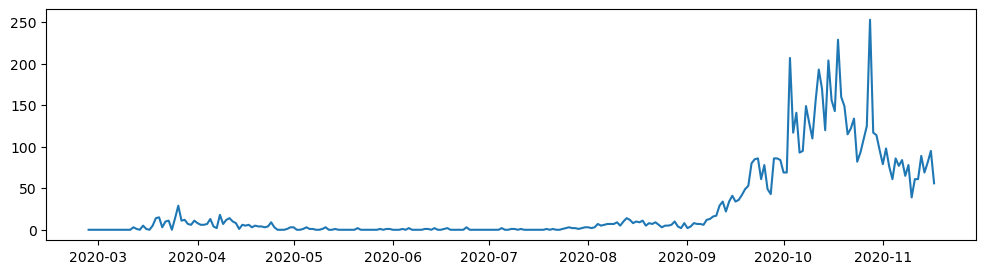

In [42]:
fig = plt.figure(figsize=(12,3))
ax = fig.add_subplot()

# using indexing to select gronigen and the daily number of cases
line_plot = ax.plot(neth_covid.loc['Groningen']['n']['total_cases'])

It is bad practice to leave out axis labels. Setting them is simple:

```python
ax.set_xlabel('Date')
ax.set_ylabel('Positive cases')
```

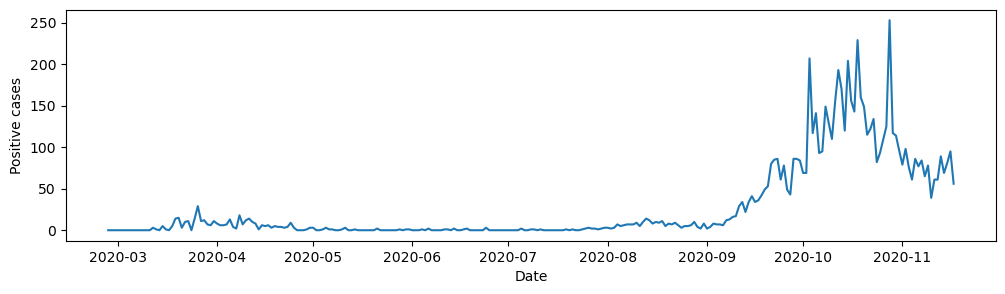

In [44]:
fig = plt.figure(figsize=(12, 3))
ax = fig.add_subplot()

_ = ax.set_xlabel('Date')
_ = ax.set_ylabel('Positive cases')

# using indexing to select gronigen and the daily number of cases
line_plot = ax.plot(neth_covid.loc['Groningen']['n']['total_cases'])

### Helping the reader

A few quick tweaks make a plot much easier to read:

- increase font size of axis labels and tick labels (`fontsize=12`, `ax.tick_params(axis='both', labelsize=12)`)
- add grid lines (`ax.grid(linestyle='--')`)
- increase line width (`lw=2.0` in `.plot`)

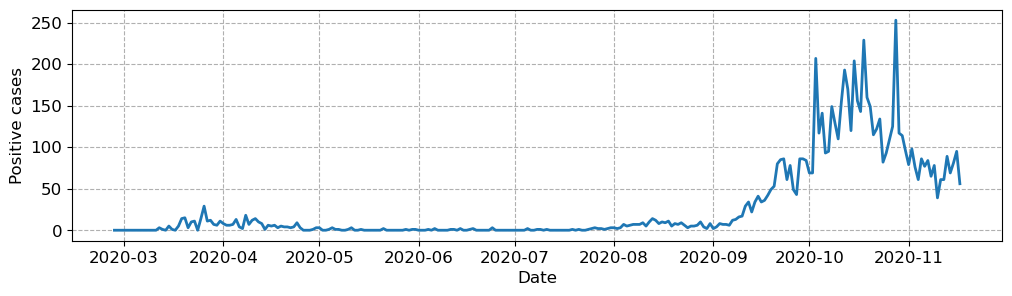

In [46]:
fig = plt.figure(figsize=(12, 3))
ax = fig.add_subplot()

_ = ax.set_xlabel('Date', fontsize=12)
_ = ax.set_ylabel('Positive cases', fontsize=12)

# x, y grid lines
_ = ax.grid(linestyle='--')

# tick label size
_ = ax.tick_params(axis='both', labelsize=12)

# lw=2.0 increases line width (default is 1.5)
line_plot = ax.plot(neth_covid.loc['Groningen']['n']['total_cases'], lw=2.0)

With these few commands `figure`, `add_subplot`, `set_xlabel`/`set_ylabel`, `grid`, `tick_params`, and `lw` you can produce a clear, readable plot for almost any dataset you'll meet in this course. Week 8 goes further into plotting multiple series with `stackplot` and fine-tuning legends with `bbox_to_anchor`, which is out of scope for this recap.

### Not covered in this recap (see original week 6–8 notebooks)

- `numpy.random` and statistical/distribution functions (week 6)
- The bootstrap resampling case study and loop-elimination techniques (week 6)
- Method chaining for multi-step cleaning pipelines (week 8)
- Multi-index / `pivot_table` reshaping (week 8)
- Plotting multiple series with `stackplot` and legend fine-tuning with `bbox_to_anchor` (week 8)